In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)

df = pd.read_csv(r"C:\Users\Admin\Desktop\CyberShield AI\ai_models\fake_job_detection\data\DataSet.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (17880, 18)

Columns:
['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent', 'in_balanced_dataset']

Data types:
title                  str
location               str
department             str
salary_range           str
company_profile        str
description            str
requirements           str
benefits               str
telecommuting          str
has_company_logo       str
has_questions          str
employment_type        str
required_experience    str
required_education     str
industry               str
function               str
fraudulent             str
in_balanced_dataset    str
dtype: object


In [3]:
print("=== TARGET: fraudulent ===")
print(df["fraudulent"].value_counts(dropna=False))

print("\n=== in_balanced_dataset ===")
print(df["in_balanced_dataset"].value_counts(dropna=False))

print("\n=== telecommuting ===")
print(df["telecommuting"].value_counts(dropna=False))

print("\n=== has_company_logo ===")
print(df["has_company_logo"].value_counts(dropna=False))

print("\n=== has_questions ===")
print(df["has_questions"].value_counts(dropna=False))

=== TARGET: fraudulent ===
fraudulent
f    17014
t      866
Name: count, dtype: int64

=== in_balanced_dataset ===
in_balanced_dataset
f    16980
t      900
Name: count, dtype: int64

=== telecommuting ===
telecommuting
f    17113
t      767
Name: count, dtype: int64

=== has_company_logo ===
has_company_logo
t    14220
f     3660
Name: count, dtype: int64

=== has_questions ===
has_questions
f    9088
t    8792
Name: count, dtype: int64


In [4]:
# Convert target temporarily for easier filtering
fraud_jobs = df[df["fraudulent"] == "t"]
genuine_jobs = df[df["fraudulent"] == "f"]

print("=== FRAUDULENT JOB EXAMPLES ===")

for i, (_, row) in enumerate(fraud_jobs.head(3).iterrows(), 1):
    print("=" * 100)
    print(f"FRAUDULENT JOB {i}")
    print("=" * 100)

    print("TITLE:")
    print(row["title"])

    print("\nDESCRIPTION:")
    print(row["description"])

    print("\nREQUIREMENTS:")
    print(row["requirements"])

    print("\nCOMPANY PROFILE:")
    print(row["company_profile"])

    print("\nBENEFITS:")
    print(row["benefits"])


print("\n\n" + "#" * 120)
print("=== GENUINE JOB EXAMPLES ===")

for i, (_, row) in enumerate(genuine_jobs.head(3).iterrows(), 1):
    print("=" * 100)
    print(f"GENUINE JOB {i}")
    print("=" * 100)

    print("TITLE:")
    print(row["title"])

    print("\nDESCRIPTION:")
    print(row["description"])

    print("\nREQUIREMENTS:")
    print(row["requirements"])

    print("\nCOMPANY PROFILE:")
    print(row["company_profile"])

    print("\nBENEFITS:")
    print(row["benefits"])

=== FRAUDULENT JOB EXAMPLES ===
FRAUDULENT JOB 1
TITLE:
IC&E Technician

DESCRIPTION:
<p><b><img src="#URL_ae07dc35dfe86ebc1101b48eec77574871f2ba0daaf971ad3f2e2246bee5b31d#"></b></p>
<p></p>
<p></p>
<p><b>IC&amp;E Technician | Bakersfield, CA Mt. Poso</b></p>
<p></p>
<p><b>Principal Duties and Responsibilities: </b></p>
<ul>
<li>Calibrates, tests, maintains, troubleshoots, and installs all power plant instrumentation, control systems and electrical equipment.</li>
<li>Performs maintenance on motor control centers, motor operated valves, generators, excitation equipment and motors.</li>
<li>Performs preventive, predictive and corrective maintenance on equipment, coordinating work with various team members.</li>
<li>Designs and installs new equipment and/or system modifications.</li>
<li>Troubleshoots and performs maintenance on DC backup power equipment, process controls, programmable logic controls (PLC), and emission monitoring equipment.</li>
<li>Uses maintenance reporting system to 

In [5]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

print(missing.sort_values("missing_count", ascending=False))

                     missing_count  missing_percentage
salary_range                 15012               83.96
department                   11547               64.58
required_education            8105               45.33
benefits                      7196               40.25
required_experience           7050               39.43
function                      6455               36.10
industry                      4903               27.42
employment_type               3471               19.41
company_profile               3308               18.50
requirements                  2689               15.04
location                       346                1.94
title                            0                0.00
description                      0                0.00
telecommuting                    0                0.00
has_company_logo                 0                0.00
has_questions                    0                0.00
fraudulent                       0                0.00
in_balance

In [6]:
# Compare missing values between genuine and fraudulent jobs

for column in df.columns:
    if column == "fraudulent":
        continue

    missing_by_class = (
        df.groupby("fraudulent")[column]
        .apply(lambda x: x.isna().mean() * 100)
    )

    print(f"\n{column}")
    print(missing_by_class)


title
fraudulent
f    0.0
t    0.0
Name: title, dtype: float64

location
fraudulent
f    1.921947
t    2.193995
Name: location, dtype: float64

department
fraudulent
f    64.746679
t    61.316397
Name: department, dtype: float64

salary_range
fraudulent
f    84.453979
t    74.249423
Name: salary_range, dtype: float64

company_profile
fraudulent
f    15.992712
t    67.782910
Name: company_profile, dtype: float64

description
fraudulent
f    0.0
t    0.0
Name: description, dtype: float64

requirements
fraudulent
f    14.905372
t    17.667436
Name: requirements, dtype: float64

benefits
fraudulent
f    40.161044
t    41.916859
Name: benefits, dtype: float64

telecommuting
fraudulent
f    0.0
t    0.0
Name: telecommuting, dtype: float64

has_company_logo
fraudulent
f    0.0
t    0.0
Name: has_company_logo, dtype: float64

has_questions
fraudulent
f    0.0
t    0.0
Name: has_questions, dtype: float64

employment_type
fraudulent
f    18.984366
t    27.829099
Name: employment_type, dtype: fl

In [7]:
# Check duplicate rows

print("Total rows:", len(df))
print("Exact duplicate rows:", df.duplicated().sum())

Total rows: 17880
Exact duplicate rows: 235


In [8]:
print("Duplicate descriptions:", df["description"].duplicated().sum())

Duplicate descriptions: 2785


In [9]:
print(
    "Duplicate title + description:",
    df.duplicated(subset=["title", "description"]).sum()
)

Duplicate title + description: 1881


In [10]:
# Check whether identical descriptions have different fraud labels

description_label_check = (
    df.groupby("description")["fraudulent"]
      .nunique()
)

print("Descriptions appearing with multiple labels:",
      (description_label_check > 1).sum())

Descriptions appearing with multiple labels: 1


In [11]:
# Check whether identical title + description combinations
# have different fraud labels

title_description_label_check = (
    df.groupby(["title", "description"])["fraudulent"]
      .nunique()
)

print(
    "Title + description combinations appearing with multiple labels:",
    (title_description_label_check > 1).sum()
)

Title + description combinations appearing with multiple labels: 0


In [12]:
# Find the description that has conflicting fraud labels

conflicting_descriptions = (
    df.groupby("description")["fraudulent"]
      .nunique()
)

conflicting_descriptions = conflicting_descriptions[
    conflicting_descriptions > 1
].index

print("Number of conflicting descriptions:",
      len(conflicting_descriptions))

for desc in conflicting_descriptions:
    rows = df[df["description"] == desc]

    print("\n" + "=" * 80)
    print("DESCRIPTION:")
    print(desc[:2000])

    print("\nROWS:")
    print(
        rows[
            ["title", "company_profile", "requirements",
             "employment_type", "industry", "fraudulent"]
        ].to_string(index=False)
    )

Number of conflicting descriptions: 1

DESCRIPTION:
<p>Workable is a product-driven software company. With thousands of enterprise users and millions in venture funding, we're building the best recruiting software in the world. A frictionless, usable, robust and highly scalable product that helps companies find and meet great people. The quality, design and usability of our software is what sets us apart from the competition. It's good to be an engineer in a company that values good engineering above all.</p>
<p><img src="#URL_d6ae991c1d312c2c0f3835e687c0f982b44085f6930870e6f356deb094e8cc31#"></p>
<p>We have a team of remarkably talented and friendly developers, a strong engineering culture and a dogged emphasis on customer-centric design. We're working on all sorts of exciting areas of application development: web, mobile, infrastructure, performance, ui/ux design, integrations with dozens of web services, API development, modern front-end frameworks, scalability, video, natural langu

In [13]:
print(
    pd.crosstab(
        df["fraudulent"],
        df["in_balanced_dataset"],
        margins=True
    )
)

in_balanced_dataset      f    t    All
fraudulent                            
f                    16564  450  17014
t                      416  450    866
All                  16980  900  17880


In [14]:
print(
    pd.crosstab(
        df["fraudulent"],
        df["in_balanced_dataset"],
        normalize="index"
    ) * 100
)

in_balanced_dataset          f          t
fraudulent                               
f                    97.355119   2.644881
t                    48.036952  51.963048


In [15]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for column in text_columns:
    print("\n" + "=" * 60)
    print(column)

    print("HTML rows:",
          df[column].fillna("").str.contains(r"<[^>]+>", regex=True).sum())

    print("URL placeholder rows:",
          df[column].fillna("").str.contains(r"#URL_", regex=True).sum())

    print("Email placeholder rows:",
          df[column].fillna("").str.contains(r"#EMAIL_", regex=True).sum())

    print("Phone placeholder rows:",
          df[column].fillna("").str.contains(r"#PHONE_", regex=True).sum())


title
HTML rows: 0
URL placeholder rows: 0
Email placeholder rows: 0
Phone placeholder rows: 0

company_profile
HTML rows: 14554
URL placeholder rows: 3302
Email placeholder rows: 313
Phone placeholder rows: 249

description
HTML rows: 17858
URL placeholder rows: 4060
Email placeholder rows: 624
Phone placeholder rows: 348

requirements
HTML rows: 15173
URL placeholder rows: 1076
Email placeholder rows: 132
Phone placeholder rows: 40

benefits
HTML rows: 10676
URL placeholder rows: 1130
Email placeholder rows: 343
Phone placeholder rows: 110


In [16]:
description_length = df["description"].fillna("").str.split().str.len()

print("\nDescription word-count statistics:")
print(description_length.describe())

print("\nDescriptions with <= 10 words:",
      (description_length <= 10).sum())

print("Descriptions with <= 20 words:",
      (description_length <= 20).sum())


Description word-count statistics:
count    17880.000000
mean       185.970526
std        163.062621
min          1.000000
25%         93.000000
50%        156.000000
75%        239.000000
max       3917.000000
Name: description, dtype: float64

Descriptions with <= 10 words: 41
Descriptions with <= 20 words: 301


In [17]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for column in text_columns:
    text = df[column].fillna("")

    print("\n" + "=" * 70)
    print(column)

    html_present = text.str.contains(
        r"<[^>]+>",
        regex=True
    )

    url_present = text.str.contains(
        r"#URL_",
        regex=True
    )

    email_present = text.str.contains(
        r"#EMAIL_",
        regex=True
    )

    phone_present = text.str.contains(
        r"#PHONE_",
        regex=True
    )

    result = pd.DataFrame({
        "fraudulent": df["fraudulent"],
        "html": html_present,
        "url": url_present,
        "email": email_present,
        "phone": phone_present
    })

    print("\nHTML presence:")
    print(pd.crosstab(
        result["fraudulent"],
        result["html"],
        normalize="index"
    ) * 100)

    print("\nURL presence:")
    print(pd.crosstab(
        result["fraudulent"],
        result["url"],
        normalize="index"
    ) * 100)

    print("\nEmail presence:")
    print(pd.crosstab(
        result["fraudulent"],
        result["email"],
        normalize="index"
    ) * 100)

    print("\nPhone presence:")
    print(pd.crosstab(
        result["fraudulent"],
        result["phone"],
        normalize="index"
    ) * 100)


title

HTML presence:
html        False
fraudulent       
f           100.0
t           100.0

URL presence:
url         False
fraudulent       
f           100.0
t           100.0

Email presence:
email       False
fraudulent       
f           100.0
t           100.0

Phone presence:
phone       False
fraudulent       
f           100.0
t           100.0

company_profile

HTML presence:
html            False      True 
fraudulent                      
f           16.098507  83.901493
t           67.782910  32.217090

URL presence:
url             False      True 
fraudulent                      
f           81.491713  18.508287
t           82.332564  17.667436

Email presence:
email           False     True 
fraudulent                     
f           98.360174  1.639826
t           96.073903  3.926097

Phone presence:
phone           False     True 
fraudulent                     
f           98.701070  1.298930
t           96.766744  3.233256

description

HTML presence:
html     

In [18]:
print(df["fraudulent"].value_counts(dropna=False))
print("\nUnique values:")
print(df["fraudulent"].unique())

fraudulent
f    17014
t      866
Name: count, dtype: int64

Unique values:
<StringArray>
['f', 't']
Length: 2, dtype: str


In [19]:
categorical_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False).head(20))


telecommuting
telecommuting
f    17113
t      767
Name: count, dtype: int64

has_company_logo
has_company_logo
t    14220
f     3660
Name: count, dtype: int64

has_questions
has_questions
f    9088
t    8792
Name: count, dtype: int64

employment_type
employment_type
Full-time    11620
NaN           3471
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

required_experience
required_experience
NaN                 7050
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

required_education
required_education
NaN                                  8105
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                     

In [20]:
%pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd
import re
from bs4 import BeautifulSoup

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # --------------------------------------------------
    # 1. Replace dataset placeholders
    # --------------------------------------------------
    text = re.sub(r"#URL_[^#]*#", " [URL] ", text)
    text = re.sub(r"#EMAIL_[^#]*#", " [EMAIL] ", text)
    text = re.sub(r"#PHONE_[^#]*#", " [PHONE] ", text)

    # --------------------------------------------------
    # 2. Remove normal HTML
    # --------------------------------------------------
    text = BeautifulSoup(text, "html.parser").get_text(" ")

    # --------------------------------------------------
    # 3. Remove HTML tags that were encoded as text
    # --------------------------------------------------
    text = re.sub(
        r"&lt;/?(?:b|i|strong|em|u|br|p|div|ul|ol|li|span)[^&]*?&gt;",
        " ",
        text,
        flags=re.IGNORECASE
    )

    # --------------------------------------------------
    # 4. Handle the specific malformed tag found in data
    # --------------------------------------------------
    text = text.replace("<x{(}>", " ")
    text = text.replace("&lt;x{(}&gt;", " ")

    # --------------------------------------------------
    # 5. Remove excessive whitespace
    # --------------------------------------------------
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [22]:
clean_df = df.copy()

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for column in text_columns:
    clean_df[column] = clean_df[column].apply(clean_text)

clean_df = clean_df.drop(columns=["in_balanced_dataset"])

clean_df.to_csv(
    "../data/DataSet_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print("Shape:", clean_df.shape)

Cleaned dataset saved successfully.
Shape: (17880, 17)


In [23]:
clean_check = pd.read_csv("../data/DataSet_cleaned.csv")

html_rows = clean_check[
    clean_check["description"].str.contains(
        r"<[^>]+>",
        regex=True,
        na=False
    )
]

print("HTML-like rows remaining:", len(html_rows))

for idx, text in html_rows["description"].items():
    print("\nROW:", idx)
    print(text[:500])

HTML-like rows remaining: 4

ROW: 1786
Appurify’s mission is to create innovative tools that help developers build higher quality, better performing mobile apps. We built the world’s most advanced mobile device cloud, which allows developers to test their app/website on real iOS or Android devices. Appurify was founded in June of 2012 and has top tier customers including Macy’s, Yahoo, Google, and Dropbox - and we’re just getting started. We’re looking for a Product Marketing Manager that can lead our go-to-market strategy. Our ideal

ROW: 3988
I am looking for an inspired UI/Ux designer with great experience in both iOS and web design to join [URL] . Our solution is at intersection of Mobile, SaaS, Productivity and Enterprise... Highly desirable space. Incredibly disruptive product vision. Must LIVE in and want to WORK in Northern NJ. We are very early stage. Sky's the limit. ----------------------- (Please include a cover email/note along with your resume, indicating why this opportu

In [24]:
def remove_encoded_formatting_tags(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Remove only formatting tags that survived as literal text
    text = re.sub(
        r"</?(?:b|i|strong|em|u|br|p|div|ul|ol|li|span)>",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(r"\s+", " ", text).strip()

    return text


for column in text_columns:
    clean_df[column] = clean_df[column].apply(
        remove_encoded_formatting_tags
    )

clean_df.to_csv(
    "../data/DataSet_cleaned.csv",
    index=False
)

print("Final cleaned dataset saved.")
print("Shape:", clean_df.shape)

Final cleaned dataset saved.
Shape: (17880, 17)


In [25]:
print("ROW 3988:")
print(clean_df.loc[3988, "description"][:1000])

print("\nROW 4020:")
print(clean_df.loc[4020, "description"][:1000])

print("\nROW 1786:")
print(clean_df.loc[1786, "description"][:500])

ROW 3988:
I am looking for an inspired UI/Ux designer with great experience in both iOS and web design to join [URL] . Our solution is at intersection of Mobile, SaaS, Productivity and Enterprise... Highly desirable space. Incredibly disruptive product vision. Must LIVE in and want to WORK in Northern NJ. We are very early stage. Sky's the limit. ----------------------- (Please include a cover email/note along with your resume, indicating why this opportunity appeals to you, and why you feel you might be a good fit for [URL] ) I need 1 innovative, talented, experienced, collaborative, communicative, fun, and knowledgeable iOS and Web UI/Ux Designer who genuinely wants to join a true startup... a very early stage startup with sky-high potential in the most desirable and lucrative space in tech right now: Mobile, SaaS, Productivity, Enterprise. You must live in and want to work in the great state of New Jersey... specifically Northern Jersey. The office will be located near Montclair, NJ

In [26]:
# Create a duplicate group based on title + description
clean_df["duplicate_group"] = (
    clean_df["title"].fillna("").astype(str).str.strip().str.lower()
    + " || "
    + clean_df["description"].fillna("").astype(str).str.strip().str.lower()
)

print("Total rows:", len(clean_df))
print("Unique title + description groups:", clean_df["duplicate_group"].nunique())
print(
    "Rows belonging to duplicate groups:",
    clean_df["duplicate_group"].duplicated(keep=False).sum()
)

Total rows: 17880
Unique title + description groups: 15499
Rows belonging to duplicate groups: 3285


In [27]:
# Check whether any duplicate title + description group
# contains both genuine and fraudulent labels

group_label_counts = (
    clean_df.groupby("duplicate_group")["fraudulent"]
    .nunique()
)

conflicting_groups = group_label_counts[group_label_counts > 1]

print("Total duplicate groups:", (group_label_counts > 1).sum())
print("Conflicting duplicate groups:", len(conflicting_groups))

Total duplicate groups: 0
Conflicting duplicate groups: 0


In [28]:
# Create one row per unique title + description group
group_df = (
    clean_df.groupby("duplicate_group", as_index=False)
    .agg(
        fraudulent=("fraudulent", "first")
    )
)

print("Total groups:", len(group_df))
print("\nClass distribution at group level:")
print(group_df["fraudulent"].value_counts())
print("\nClass percentages:")
print(group_df["fraudulent"].value_counts(normalize=True) * 100)

Total groups: 15499

Class distribution at group level:
fraudulent
f    14835
t      664
Name: count, dtype: int64

Class percentages:
fraudulent
f    95.715853
t     4.284147
Name: proportion, dtype: float64


In [29]:
from sklearn.model_selection import StratifiedGroupKFold

X = clean_df.drop(columns=["fraudulent"])
y = clean_df["fraudulent"]
groups = clean_df["duplicate_group"]

print("Rows:", len(X))
print("Groups:", groups.nunique())
print("Fraud rate:", (y == "t").mean())

Rows: 17880
Groups: 15499
Fraud rate: 0.04843400447427293


In [30]:
from sklearn.model_selection import train_test_split

# One row per unique duplicate group
groups_df = group_df.copy()

# First: 70% groups → train, 30% → temporary
train_groups, temp_groups = train_test_split(
    groups_df,
    test_size=0.30,
    stratify=groups_df["fraudulent"],
    random_state=42
)

# Second: split the temporary 30% into 15% validation + 15% test
val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    stratify=temp_groups["fraudulent"],
    random_state=42
)

print("Train groups:", len(train_groups))
print("Validation groups:", len(val_groups))
print("Test groups:", len(test_groups))

print("\nTrain fraud rate:",
      (train_groups["fraudulent"] == "t").mean())

print("Validation fraud rate:",
      (val_groups["fraudulent"] == "t").mean())

print("Test fraud rate:",
      (test_groups["fraudulent"] == "t").mean())

Train groups: 10849
Validation groups: 2325
Test groups: 2325

Train fraud rate: 0.042861093188312285
Validation fraud rate: 0.043010752688172046
Test fraud rate: 0.04258064516129032


The important thing now is to map these groups back to the original rows and check:

- How many actual job postings/rows are in each split?
- How many fraudulent rows are in each?
- What is the actual row-level fraud rate?
- Most importantly, does any duplicate group appear in more than one split?

In [31]:
# Get group IDs for each split
train_group_ids = set(train_groups["duplicate_group"])
val_group_ids = set(val_groups["duplicate_group"])
test_group_ids = set(test_groups["duplicate_group"])

# Map original rows to their split
train_df = clean_df[clean_df["duplicate_group"].isin(train_group_ids)].copy()
val_df = clean_df[clean_df["duplicate_group"].isin(val_group_ids)].copy()
test_df = clean_df[clean_df["duplicate_group"].isin(test_group_ids)].copy()

# Row-level statistics
for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    fraud_count = (data["fraudulent"] == "t").sum()
    fraud_rate = (data["fraudulent"] == "t").mean() * 100

    print(f"{name}:")
    print("  Rows:", len(data))
    print("  Fraud rows:", fraud_count)
    print("  Genuine rows:", len(data) - fraud_count)
    print("  Fraud rate:", round(fraud_rate, 3), "%")
    print()

# Check for group overlap
print("Train ∩ Validation:", len(train_group_ids & val_group_ids))
print("Train ∩ Test:", len(train_group_ids & test_group_ids))
print("Validation ∩ Test:", len(val_group_ids & test_group_ids))

Train:
  Rows: 12301
  Fraud rows: 603
  Genuine rows: 11698
  Fraud rate: 4.902 %

Validation:
  Rows: 2602
  Fraud rows: 130
  Genuine rows: 2472
  Fraud rate: 4.996 %

Test:
  Rows: 2977
  Fraud rows: 133
  Genuine rows: 2844
  Fraud rate: 4.468 %

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [32]:
categorical_cols = [
    "employment_type",
    "required_experience",
    "required_education",
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col)

    summary = (
        train_df.groupby(col, dropna=False)["fraudulent"]
        .agg(
            total="count",
            fraud_count=lambda x: (x == "t").sum(),
            fraud_rate=lambda x: (x == "t").mean() * 100
        )
        .sort_values("fraud_rate", ascending=False)
    )

    print(summary)


employment_type
                 total  fraud_count  fraud_rate
employment_type                                
Part-time          535           53    9.906542
NaN               2361          154    6.522660
Full-time         8165          352    4.311084
Other              170            7    4.117647
Contract           897           36    4.013378
Temporary          173            1    0.578035

required_experience
                     total  fraud_count  fraud_rate
required_experience                                
Executive              108            9    8.333333
NaN                   4628          293    6.331029
Entry level           1933          116    6.001035
Not Applicable         790           44    5.569620
Director               289           14    4.844291
Mid-Senior level      2662           87    3.268219
Internship             262            7    2.671756
Associate             1629           33    2.025783

required_education
                                   tot

C:\Users\Admin\AppData\Local\Temp\ipykernel_18532\2517058581.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Genuine", "Fraudulent"])


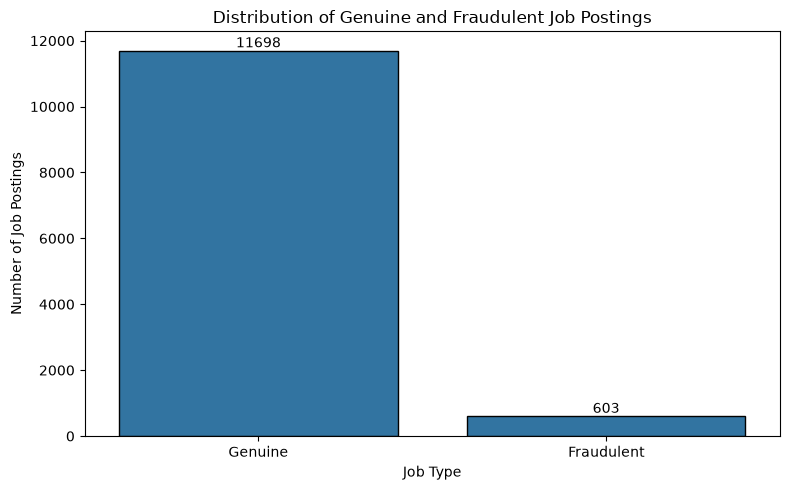

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count fraudulent vs genuine jobs
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=train_df,
    x="fraudulent",
    order=["f", "t"],
    edgecolor="black"
)

plt.title("Distribution of Genuine and Fraudulent Job Postings")
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")

# Add meaningful labels
ax.set_xticklabels(["Genuine", "Fraudulent"])

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

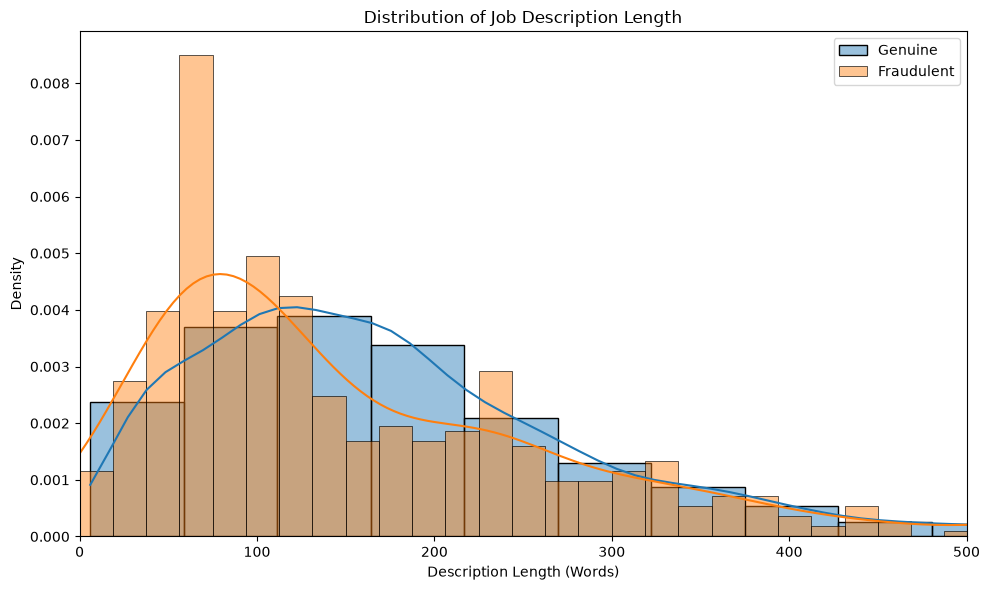

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = train_df.copy()

# Calculate description length
plot_df["description_word_count"] = (
    plot_df["description"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

# Separate the two classes
genuine = plot_df.loc[
    plot_df["fraudulent"] == "f",
    "description_word_count"
]

fraudulent = plot_df.loc[
    plot_df["fraudulent"] == "t",
    "description_word_count"
]

plt.figure(figsize=(10, 6))

# Use density so class imbalance doesn't dominate the graph
sns.histplot(
    genuine,
    bins=40,
    stat="density",
    alpha=0.45,
    label="Genuine",
    kde=True
)

sns.histplot(
    fraudulent,
    bins=40,
    stat="density",
    alpha=0.45,
    label="Fraudulent",
    kde=True
)

plt.xlim(0, 500)

plt.title("Distribution of Job Description Length")
plt.xlabel("Description Length (Words)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

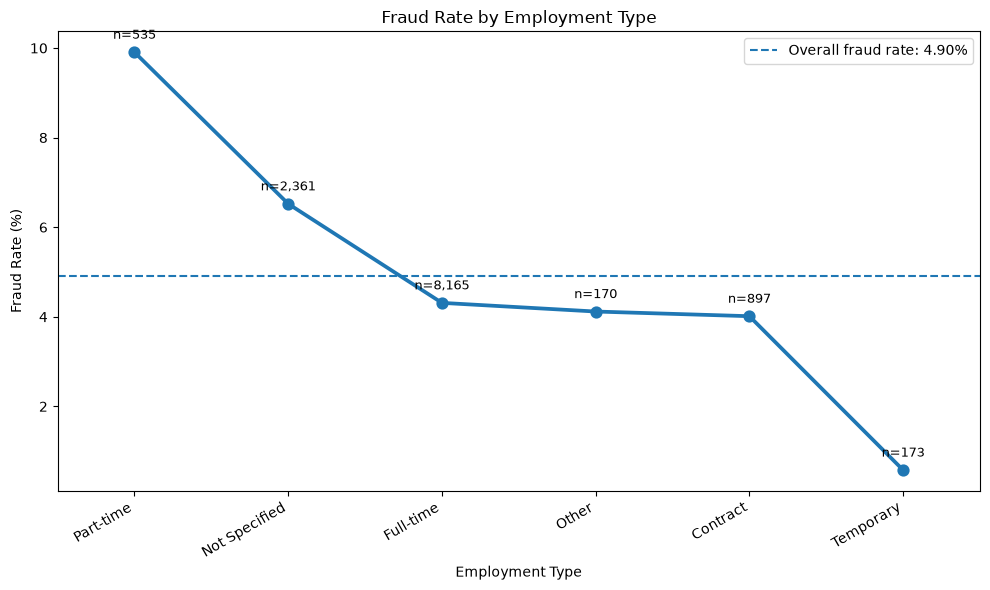

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = train_df.copy()

# Calculate fraud rate (%) for each employment type
employment_stats = (
    plot_df.groupby("employment_type", dropna=False)
    .agg(
        fraud_rate=("fraudulent", lambda x: (x == "t").mean() * 100),
        total_jobs=("fraudulent", "size")
    )
    .reset_index()
)

# Replace missing category for display
employment_stats["employment_type"] = employment_stats["employment_type"].fillna(
    "Not Specified"
)

# Sort by fraud rate
employment_stats = employment_stats.sort_values(
    "fraud_rate",
    ascending=False
)

# Overall fraud rate
overall_fraud_rate = (plot_df["fraudulent"] == "t").mean() * 100

plt.figure(figsize=(10, 6))

ax = sns.pointplot(
    data=employment_stats,
    x="employment_type",
    y="fraud_rate",
    errorbar=None,
    markers="o",
    linestyles="-"
)

# Overall fraud-rate reference line
plt.axhline(
    overall_fraud_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall fraud rate: {overall_fraud_rate:.2f}%"
)

# Add sample size above each point
for i, row in employment_stats.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["fraud_rate"] + 0.3,
        f"n={row['total_jobs']:,}",
        ha="center",
        fontsize=9
    )

plt.title("Fraud Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.legend()

plt.tight_layout()
plt.show()

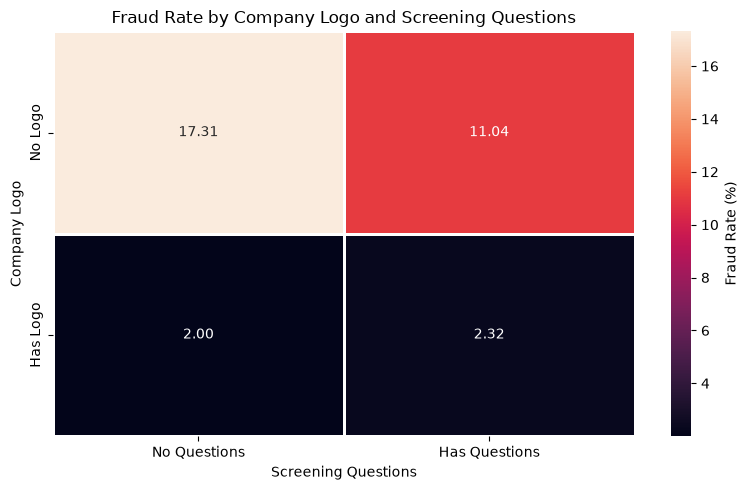

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = train_df.copy()

# Calculate fraud rate for each combination
heatmap_data = (
    plot_df.pivot_table(
        index="has_company_logo",
        columns="has_questions",
        values="fraudulent",
        aggfunc=lambda x: (x == "t").mean() * 100
    )
)

# Rename values for readability
heatmap_data.index = heatmap_data.index.map({
    "f": "No Logo",
    "t": "Has Logo"
})

heatmap_data.columns = heatmap_data.columns.map({
    "f": "No Questions",
    "t": "Has Questions"
})

plt.figure(figsize=(8, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    linewidths=1,
    cbar_kws={"label": "Fraud Rate (%)"}
)

plt.title("Fraud Rate by Company Logo and Screening Questions")
plt.xlabel("Screening Questions")
plt.ylabel("Company Logo")

plt.tight_layout()
plt.show()

In [37]:
# Inspect training data before feature engineering

print("Shape:", train_df.shape)
print("\nColumns:")
print(train_df.columns.tolist())

print("\nData Types:")
print(train_df.dtypes)

print("\nTarget Distribution:")
print(train_df["fraudulent"].value_counts())

Shape: (12301, 18)

Columns:
['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent', 'duplicate_group']

Data Types:
title                  str
location               str
department             str
salary_range           str
company_profile        str
description            str
requirements           str
benefits               str
telecommuting          str
has_company_logo       str
has_questions          str
employment_type        str
required_experience    str
required_education     str
industry               str
function               str
fraudulent             str
duplicate_group        str
dtype: object

Target Distribution:
fraudulent
f    11698
t      603
Name: count, dtype: int64


In [38]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

def combine_text(row):
    return (
        "[TITLE] " + str(row["title"]) +
        " [COMPANY] " + str(row["company_profile"]) +
        " [DESCRIPTION] " + str(row["description"]) +
        " [REQUIREMENTS] " + str(row["requirements"]) +
        " [BENEFITS] " + str(row["benefits"])
    )

train_df["combined_text"] = train_df.apply(combine_text, axis=1)
val_df["combined_text"] = val_df.apply(combine_text, axis=1)
test_df["combined_text"] = test_df.apply(combine_text, axis=1)

print("Train:", train_df["combined_text"].shape)
print("Validation:", val_df["combined_text"].shape)
print("Test:", test_df["combined_text"].shape)

print("\nExample:")
print(train_df["combined_text"].iloc[0][:1000])

Train: (12301,)
Validation: (2602,)
Test: (2977,)

Example:
[TITLE] Customer Service - Cloud Video Production [COMPANY] 90 Seconds, the worlds Cloud Video Production Service. 90 Seconds is the worlds Cloud Video Production Service enabling brands and agencies to get high quality online video content shot and produced anywhere in the world. 90 Seconds makes video production fast, affordable, and all managed seamlessly in the cloud from purchase to publish. http://90 [URL] 90 Seconds removes the hassle, cost, risk and speed issues of working with regular video production companies by managing every aspect of video projects in a beautiful online experience. With a growing global network of over 2,000 rated video professionals in over 50 countries managed by dedicated production success teams in 5 countries, 90 Seconds provides a 100% success guarantee. 90 Seconds has produced almost 4,000 videos in over 30 Countries for over 500 Global brands including some of the worlds largest including

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Learn the vocabulary ONLY from training data
X_train_text = tfidf.fit_transform(train_df["combined_text"])

# Apply the same learned TF-IDF representation
X_val_text = tfidf.transform(val_df["combined_text"])
X_test_text = tfidf.transform(test_df["combined_text"])

print("TF-IDF vocabulary size:", len(tfidf.vocabulary_))

print("\nTrain matrix shape:", X_train_text.shape)
print("Validation matrix shape:", X_val_text.shape)
print("Test matrix shape:", X_test_text.shape)

In [ ]:
import numpy as np

print("Non-zero values:")
print("Train:", X_train_text.nnz)
print("Validation:", X_val_text.nnz)
print("Test:", X_test_text.nnz)

print("\nSparsity:")

train_total = X_train_text.shape[0] * X_train_text.shape[1]

sparsity = 1 - (X_train_text.nnz / train_total)

print(f"Train sparsity: {sparsity:.4%}")

print("\nAverage non-zero features per training document:")

avg_nonzero = X_train_text.nnz / X_train_text.shape[0]

print(f"{avg_nonzero:.2f}")

Non-zero values:
Train: 4482719
Validation: 887844
Test: 941412

Sparsity:
Train sparsity: 99.8876%

Average non-zero features per training document:
364.42


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create target variables
y_train = train_df["fraudulent"]
y_val = val_df["fraudulent"]
y_test = test_df["fraudulent"]

# Logistic Regression baseline
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train only on the training data
lr_model.fit(X_train_text, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

print("Threshold Analysis")
print("-" * 65)
print(f"{'Threshold':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}{'Fraud Flags':<12}")

for threshold in thresholds:

    y_val_pred_threshold = np.where(
        y_val_proba >= threshold,
        "t",
        "f"
    )

    precision = precision_score(
        y_val,
        y_val_pred_threshold,
        pos_label="t"
    )

    recall = recall_score(
        y_val,
        y_val_pred_threshold,
        pos_label="t"
    )

    f1 = f1_score(
        y_val,
        y_val_pred_threshold,
        pos_label="t"
    )

    fraud_flags = np.sum(y_val_pred_threshold == "t")

    print(
        f"{threshold:<12.2f}"
        f"{precision:<12.4f}"
        f"{recall:<12.4f}"
        f"{f1:<12.4f}"
        f"{fraud_flags:<12}"
    )

Threshold Analysis
-----------------------------------------------------------------
Threshold   Precision   Recall      F1          Fraud Flags 


NameError: name 'y_val_proba' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix

selected_thresholds = [0.40, 0.50, 0.60, 0.70]

print("Confusion Matrix by Threshold")
print("=" * 60)

for threshold in selected_thresholds:

    y_pred = np.where(
        y_val_proba >= threshold,
        "t",
        "f"
    )

    cm = confusion_matrix(
        y_val,
        y_pred,
        labels=["f", "t"]
    )

    tn, fp, fn, tp = cm.ravel()

    print(f"\nThreshold: {threshold}")
    print(f"True Negatives  (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives   (TP): {tp}")

Confusion Matrix by Threshold

Threshold: 0.4
True Negatives  (TN): 2421
False Positives (FP): 51
False Negatives (FN): 10
True Positives   (TP): 120

Threshold: 0.5
True Negatives  (TN): 2456
False Positives (FP): 16
False Negatives (FN): 15
True Positives   (TP): 115

Threshold: 0.6
True Negatives  (TN): 2466
False Positives (FP): 6
False Negatives (FN): 21
True Positives   (TP): 109

Threshold: 0.7
True Negatives  (TN): 2470
False Positives (FP): 2
False Negatives (FN): 27
True Positives   (TP): 103


A score near 0 means the example is close to the decision boundary.

A strongly positive score means the model considers it more likely to belong to the fraud class.

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_text, y_train)

print("Linear SVM training completed.")

Linear SVM training completed.


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)
import numpy as np

# Get SVM decision scores
svm_scores = svm_model.decision_function(X_val_text)

# Make sure positive score corresponds to fraudulent class "t"
if list(svm_model.classes_)[1] != "t":
    svm_scores = -svm_scores

# Default SVM decision boundary = 0
y_val_pred_svm = np.where(
    svm_scores >= 0,
    "t",
    "f"
)

precision = precision_score(y_val, y_val_pred_svm, pos_label="t")
recall = recall_score(y_val, y_val_pred_svm, pos_label="t")
f1 = f1_score(y_val, y_val_pred_svm, pos_label="t")

# PR-AUC using SVM decision scores
y_val_binary = (y_val == "t").astype(int)
pr_auc = average_precision_score(y_val_binary, svm_scores)

cm = confusion_matrix(
    y_val,
    y_val_pred_svm,
    labels=["f", "t"]
)

tn, fp, fn, tp = cm.ravel()

print("Linear SVM - Validation Results")
print("=" * 50)
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

print("\nConfusion Matrix")
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives   (TP): {tp}")

Linear SVM - Validation Results
Precision : 0.9735
Recall    : 0.8462
F1 Score  : 0.9053
PR-AUC    : 0.9533

Confusion Matrix
True Negatives  (TN): 2469
False Positives (FP): 3
False Negatives (FN): 20
True Positives   (TP): 110


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

selected_thresholds = [-1.0, -0.5, 0.0, 0.5, 1.0]

print("SVM Threshold Analysis")
print("=" * 65)
print(f"{'Threshold':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}{'Fraud Flags'}")

for threshold in selected_thresholds:

    y_pred = np.where(
        svm_scores >= threshold,
        "t",
        "f"
    )

    precision = precision_score(
        y_val,
        y_pred,
        pos_label="t",
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        pos_label="t",
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        pos_label="t",
        zero_division=0
    )

    fraud_flags = np.sum(y_pred == "t")

    print(
        f"{threshold:<12.1f}"
        f"{precision:<12.4f}"
        f"{recall:<12.4f}"
        f"{f1:<12.4f}"
        f"{fraud_flags}"
    )

SVM Threshold Analysis
Threshold   Precision   Recall      F1          Fraud Flags
-1.0        0.1285      0.9923      0.2275      1004
-0.5        0.6649      0.9462      0.7810      185
0.0         0.9735      0.8462      0.9053      113
0.5         0.9888      0.6769      0.8037      89
1.0         1.0000      0.3000      0.4615      39


In [ ]:
structured_cols = [
    "location",
    "department",
    "salary_range",
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

for col in structured_cols:
    print(f"\n{'='*60}")
    print(f"{col}")
    print(f"Unique values: {clean_df[col].nunique()}")
    print(clean_df[col].value_counts(dropna=False).head(20))


location
Unique values: 3105
location
GB, LND, London          718
US, NY, New York         658
US, CA, San Francisco    472
GR, I, Athens            464
NaN                      346
US, ,                    339
US, TX, Houston          269
US, IL, Chicago          255
US, DC, Washington       251
DE, BE, Berlin           221
NZ, N, Auckland          218
US, CA, Los Angeles      185
GB, , London             179
US, TX, Austin           174
US, CA, San Diego        164
GB, ,                    138
US, GA, Atlanta          135
GB, LND,                 131
US, OR, Portland         131
CA, ON, Toronto          123
Name: count, dtype: int64

department
Unique values: 1337
department
NaN                       11547
Sales                       551
Engineering                 487
Marketing                   401
Operations                  270
IT                          225
Development                 146
Product                     112
Information Technology       86
Design                  

In [ ]:
# Check the raw structured features before feature engineering

structured_cols = [
    "location",
    "department",
    "salary_range",
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

print("Structured feature table shape:")
print(train_df[structured_cols].shape)

print("\nData types:")
print(train_df[structured_cols].dtypes)

print("\nMissing values:")
print(train_df[structured_cols].isna().sum())

Structured feature table shape:
(12301, 11)

Data types:
location               str
department             str
salary_range           str
telecommuting          str
has_company_logo       str
has_questions          str
employment_type        str
required_experience    str
required_education     str
industry               str
function               str
dtype: object

Missing values:
location                 242
department              7845
salary_range           10243
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         2361
required_experience     4628
required_education      5614
industry                3365
function                4232
dtype: int64


In [ ]:
for col in ["telecommuting", "has_company_logo", "has_questions"]:
    print(f"\n{col}")
    
    fraud_rate = (
        train_df.groupby(col)["fraudulent"]
        .apply(lambda x: (x == "t").mean() * 100)
    )
    
    print(fraud_rate)


telecommuting
telecommuting
f    4.788637
t    7.352941
Name: fraudulent, dtype: float64

has_company_logo
has_company_logo
f    15.650080
t     2.171475
Name: fraudulent, dtype: float64

has_questions
has_questions
f    6.402008
t    3.289474
Name: fraudulent, dtype: float64


In [ ]:
import re

salary = train_df["salary_range"].dropna().astype(str).str.strip()

pattern = salary.str.match(r"^\d+(?:\.\d+)?-\d+(?:\.\d+)?$")

print("Total non-missing salary values:", len(salary))
print("Valid min-max format:", pattern.sum())
print("Other formats:", (~pattern).sum())

print("\nOther formats:")
print(salary[~pattern].value_counts().head(20))

Total non-missing salary values: 2058
Valid min-max format: 2057
Other formats: 1

Other formats:
salary_range
40000    1
Name: count, dtype: int64


In [ ]:
import numpy as np

def extract_salary_features(df):
    result = pd.DataFrame(index=df.index)

    salary = df["salary_range"].astype("string").str.strip()

    # Whether salary information is present
    result["salary_present"] = salary.notna().astype(int)

    # Extract min and max from normal min-max format
    extracted = salary.str.extract(
        r"^(\d+(?:\.\d+)?)-(\d+(?:\.\d+)?)$"
    )

    result["salary_min"] = pd.to_numeric(extracted[0], errors="coerce")
    result["salary_max"] = pd.to_numeric(extracted[1], errors="coerce")

    # Handle single numeric salary such as "40000"
    single_salary = pd.to_numeric(salary, errors="coerce")

    result["salary_min"] = result["salary_min"].fillna(single_salary)
    result["salary_max"] = result["salary_max"].fillna(single_salary)

    # Derived features
    result["salary_mid"] = (
        result["salary_min"] + result["salary_max"]
    ) / 2

    result["salary_range_width"] = (
        result["salary_max"] - result["salary_min"]
    )

    # Fill numeric missing values after preserving salary_present
    numeric_cols = [
        "salary_min",
        "salary_max",
        "salary_mid",
        "salary_range_width"
    ]

    result[numeric_cols] = result[numeric_cols].fillna(0)

    return result


train_salary = extract_salary_features(train_df)
val_salary = extract_salary_features(val_df)
test_salary = extract_salary_features(test_df)

print("Training salary features:")
print(train_salary.head(10))

print("\nShape:", train_salary.shape)

print("\nMissing values:")
print(train_salary.isna().sum())

Training salary features:
    salary_present  salary_min  salary_max  salary_mid  salary_range_width
1                0           0           0         0.0                   0
2                0           0           0         0.0                   0
3                0           0           0         0.0                   0
5                0           0           0         0.0                   0
6                1       20000       28000     24000.0                8000
7                0           0           0         0.0                   0
8                0           0           0         0.0                   0
9                0           0           0         0.0                   0
10               1      100000      120000    110000.0               20000
15               1      120000      150000    135000.0               30000

Shape: (12301, 5)

Missing values:
salary_present        0
salary_min            0
salary_max            0
salary_mid            0
salary_range_widt

salary_present = 0 → salary was missing
salary_present = 1 → salary was provided

In [ ]:
categorical_cols = [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

train_cat = train_df[categorical_cols].copy()
val_cat = val_df[categorical_cols].copy()
test_cat = test_df[categorical_cols].copy()

# Treat missing values as their own category
for col in categorical_cols:
    train_cat[col] = train_cat[col].fillna("Missing")
    val_cat[col] = val_cat[col].fillna("Missing")
    test_cat[col] = test_cat[col].fillna("Missing")

print("Training categorical features:")
print(train_cat.head())

print("\nMissing values after replacement:")
print(train_cat.isna().sum())

Training categorical features:
  employment_type required_experience required_education  \
1       Full-time      Not Applicable            Missing   
2         Missing             Missing            Missing   
3       Full-time    Mid-Senior level  Bachelor's Degree   
5         Missing             Missing            Missing   
6       Full-time    Mid-Senior level    Master's Degree   

                    industry          function  
1  Marketing and Advertising  Customer Service  
2                    Missing           Missing  
3          Computer Software             Sales  
5                    Missing           Missing  
6               Online Media        Management  

Missing values after replacement:
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
dtype: int64


In [ ]:
## one-hot encoder
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

X_train_cat = encoder.fit_transform(train_cat)
X_val_cat = encoder.transform(val_cat)
X_test_cat = encoder.transform(test_cat)

print("Training categorical shape:", X_train_cat.shape)
print("Validation categorical shape:", X_val_cat.shape)
print("Test categorical shape:", X_test_cat.shape)

print("\nTotal encoded features:", X_train_cat.shape[1])

Training categorical shape: (12301, 194)
Validation categorical shape: (2602, 194)
Test categorical shape: (2977, 194)

Total encoded features: 194


In [ ]:
def extract_country(df):
    location = df["location"].astype("string").str.strip()
    
    country = location.str.extract(
        r"^([^,]+)"
    )[0].str.strip()
    
    return country.fillna("Missing")


train_country = extract_country(train_df)
val_country = extract_country(val_df)
test_country = extract_country(test_df)

print("Unique countries in training:", train_country.nunique())

print("\nTop countries:")
print(train_country.value_counts().head(20))

print("\nMissing:")
print((train_country == "Missing").sum())

Unique countries in training: 85

Top countries:
0
US         7237
GB         1660
GR          660
CA          320
DE          271
Missing     242
NZ          235
IN          184
AU          160
PH           99
NL           96
BE           83
IE           75
SG           60
EE           57
HK           52
FR           49
PL           47
IL           46
ES           46
Name: count, dtype: Int64

Missing:
242


In [ ]:
from sklearn.preprocessing import OneHotEncoder

location_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

X_train_location = location_encoder.fit_transform(
    train_location[["country", "state"]]
)

X_val_location = location_encoder.transform(
    extract_location_parts(val_df)[["country", "state"]]
)

X_test_location = location_encoder.transform(
    extract_location_parts(test_df)[["country", "state"]]
)

print("Training location shape:", X_train_location.shape)
print("Validation location shape:", X_val_location.shape)
print("Test location shape:", X_test_location.shape)

print("Total location features:", X_train_location.shape[1])

Training location shape: (12301, 377)
Validation location shape: (2602, 377)
Test location shape: (2977, 377)
Total location features: 377


In [ ]:
print("Unique departments:", train_df["department"].nunique())
print("Missing departments:", train_df["department"].isna().sum())
print("Missing %:", train_df["department"].isna().mean() * 100)

print("\nTop departments:")
print(train_df["department"].value_counts(dropna=False).head(20))

Unique departments: 1051
Missing departments: 7845
Missing %: 63.77530282090888

Top departments:
department
NaN                       7845
Sales                      386
Engineering                346
Marketing                  288
Operations                 193
IT                         157
Development                101
Product                     78
Information Technology      65
Design                      53
Customer Service            50
Technology                  44
Finance                     44
HR                          41
tech                        38
R&D                         35
Creative                    32
Client Services             30
Retail                      28
Administrative              27
Name: count, dtype: int64


In [ ]:
dept_fraud = (
    train_df.groupby(
        train_df["department"].fillna("Missing")
    )["fraudulent"]
    .agg(["count", lambda x: (x == "t").mean()])
    .rename(columns={"<lambda_0>": "fraud_rate"})
    .sort_values("count", ascending=False)
)

print(dept_fraud.head(20))

                        count  fraud_rate
department                               
Missing                  7845    0.044614
Sales                     386    0.010363
Engineering               346    0.095376
Marketing                 288    0.006944
Operations                193    0.000000
IT                        157    0.000000
Development               101    0.000000
Product                    78    0.000000
Information Technology     65    0.184615
Design                     53    0.000000
Customer Service           50    0.220000
Finance                    44    0.000000
Technology                 44    0.022727
HR                         41    0.048780
tech                       38    0.000000
R&D                        35    0.000000
Creative                   32    0.000000
Client Services            30    0.066667
Retail                     28    0.000000
Administrative             27    0.444444


In [ ]:
dept_counts = (
    train_df["department"]
    .fillna("Missing")
    .value_counts()
)

for threshold in [5, 10, 20, 50]:
    print(
        f"Departments with >= {threshold} jobs:",
        (dept_counts >= threshold).sum()
    )

Departments with >= 5 jobs: 132
Departments with >= 10 jobs: 64
Departments with >= 20 jobs: 30
Departments with >= 50 jobs: 11


In [ ]:
def prepare_department(df, min_count=10):
    department = df["department"].fillna("Missing").astype(str).str.strip()

    # Categories that occur at least 10 times
    frequent = department.value_counts()
    frequent = frequent[frequent >= min_count].index

    # Keep frequent departments, group the rest
    department = department.where(
        department.isin(frequent) | (department == "Missing"),
        "Other"
    )

    return department


train_department = prepare_department(train_df)
val_department = prepare_department(val_df)
test_department = prepare_department(test_df)

print("Training department categories:",
      train_department.nunique())

print("\nTop categories:")
print(train_department.value_counts().head(20))

Training department categories: 63

Top categories:
department
Missing                   7845
Other                     1676
Sales                      397
Engineering                359
Marketing                  301
Operations                 197
IT                         160
Development                106
Product                     79
Information Technology      76
Design                      56
Customer Service            52
Technology                  46
Finance                     46
HR                          41
tech                        38
R&D                         35
Client Services             32
Creative                    32
Retail                      28
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import OneHotEncoder

department_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

X_train_department = department_encoder.fit_transform(
    train_department.to_frame()
)

X_val_department = department_encoder.transform(
    val_department.to_frame()
)

X_test_department = department_encoder.transform(
    test_department.to_frame()
)

print("Training department shape:", X_train_department.shape)
print("Validation department shape:", X_val_department.shape)
print("Test department shape:", X_test_department.shape)

Training department shape: (12301, 63)
Validation department shape: (2602, 63)
Test department shape: (2977, 63)


In [ ]:
binary_cols = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

train_binary = train_df[binary_cols].replace({"f": 0, "t": 1}).astype(int)
val_binary = val_df[binary_cols].replace({"f": 0, "t": 1}).astype(int)
test_binary = test_df[binary_cols].replace({"f": 0, "t": 1}).astype(int)

print("Training:", train_binary.shape)
print("Validation:", val_binary.shape)
print("Test:", test_binary.shape)

Training: (12301, 3)
Validation: (2602, 3)
Test: (2977, 3)


In [ ]:
def extract_salary_features(df):
    result = pd.DataFrame(index=df.index)

    salary = df["salary_range"].astype("string").str.strip()

    result["salary_present"] = salary.notna().astype(int)

    extracted = salary.str.extract(
        r"^(\d+(?:\.\d+)?)-(\d+(?:\.\d+)?)$"
    )

    result["salary_min"] = pd.to_numeric(
        extracted[0], errors="coerce"
    )
    result["salary_max"] = pd.to_numeric(
        extracted[1], errors="coerce"
    )

    single_salary = pd.to_numeric(
        salary, errors="coerce"
    )

    result["salary_min"] = result["salary_min"].fillna(single_salary)
    result["salary_max"] = result["salary_max"].fillna(single_salary)

    result["salary_mid"] = (
        result["salary_min"] + result["salary_max"]
    ) / 2

    result["salary_range_width"] = (
        result["salary_max"] - result["salary_min"]
    )

    numeric_cols = [
        "salary_min",
        "salary_max",
        "salary_mid",
        "salary_range_width"
    ]

    result[numeric_cols] = result[numeric_cols].fillna(0)

    return result


train_salary = extract_salary_features(train_df)
val_salary = extract_salary_features(val_df)
test_salary = extract_salary_features(test_df)

print("Training:", train_salary.shape)
print("Validation:", val_salary.shape)
print("Test:", test_salary.shape)

Training: (12301, 5)
Validation: (2602, 5)
Test: (2977, 5)


In [ ]:
for name in [
    "train_binary",
    "train_salary",
    "X_train_cat",
    "X_train_location",
    "X_train_department"
]:
    obj = globals()[name]
    print(name, "→", type(obj), "→", getattr(obj, "dtype", "no dtype"))

train_binary → <class 'pandas.DataFrame'> → no dtype
train_salary → <class 'pandas.DataFrame'> → no dtype
X_train_cat → <class 'scipy.sparse._csr.csr_matrix'> → float64
X_train_location → <class 'scipy.sparse._csr.csr_matrix'> → float64
X_train_department → <class 'scipy.sparse._csr.csr_matrix'> → float64


In [ ]:
train_salary = train_salary.astype("float64")
val_salary = val_salary.astype("float64")
test_salary = test_salary.astype("float64")

In [ ]:
from scipy.sparse import hstack

X_train_structured = hstack([
    train_binary,
    train_salary,
    X_train_cat,
    X_train_location,
    X_train_department
]).tocsr()

X_val_structured = hstack([
    val_binary,
    val_salary,
    X_val_cat,
    X_val_location,
    X_val_department
]).tocsr()

X_test_structured = hstack([
    test_binary,
    test_salary,
    X_test_cat,
    X_test_location,
    X_test_department
]).tocsr()

print("Training:", X_train_structured.shape)
print("Validation:", X_val_structured.shape)
print("Test:", X_test_structured.shape)

Training: (12301, 642)
Validation: (2602, 642)
Test: (2977, 642)


In [ ]:
from sklearn.svm import LinearSVC

structured_svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

structured_svm.fit(X_train_structured, y_train)

print("Structured-only SVM training completed.")

Structured-only SVM training completed.


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

structured_scores = structured_svm.decision_function(X_val_structured)

if list(structured_svm.classes_)[1] != "t":
    structured_scores = -structured_scores

structured_pred = (structured_scores >= 0).astype(int)

# Convert actual labels: t = 1, f = 0
y_val_binary = (y_val == "t").astype(int)

print("Precision:", precision_score(y_val_binary, structured_pred))
print("Recall:", recall_score(y_val_binary, structured_pred))
print("F1:", f1_score(y_val_binary, structured_pred))
print("PR-AUC:", average_precision_score(y_val_binary, structured_scores))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_binary, structured_pred))

Precision: 0.1440677966101695
Recall: 0.9153846153846154
F1: 0.2489539748953975
PR-AUC: 0.37348300984680627

Confusion Matrix:
[[1765  707]
 [  11  119]]


In [ ]:
from scipy.sparse import hstack

X_train_combined = hstack([
    X_train_text,
    X_train_structured
]).tocsr()

X_val_combined = hstack([
    X_val_text,
    X_val_structured
]).tocsr()

X_test_combined = hstack([
    X_test_text,
    X_test_structured
]).tocsr()

print("Training:", X_train_combined.shape)
print("Validation:", X_val_combined.shape)
print("Test:", X_test_combined.shape)

Training: (12301, 324746)
Validation: (2602, 324746)
Test: (2977, 324746)


In [ ]:
from sklearn.svm import LinearSVC

combined_svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

combined_svm.fit(X_train_combined, y_train)

print("Combined SVM training completed.")

Combined SVM training completed.


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
import numpy as np

salary_numeric_cols = [
    "salary_min",
    "salary_max",
    "salary_mid",
    "salary_range_width"
]

train_salary_log = train_salary.copy()
val_salary_log = val_salary.copy()
test_salary_log = test_salary.copy()

for col in salary_numeric_cols:
    train_salary_log[col] = np.log1p(train_salary_log[col])
    val_salary_log[col] = np.log1p(val_salary_log[col])
    test_salary_log[col] = np.log1p(test_salary_log[col])

print(train_salary_log.describe())

       salary_present    salary_min    salary_max    salary_mid  \
count    12301.000000  12301.000000  12301.000000  12301.000000   
mean         0.167303      1.567142      1.659437      1.633932   
std          0.373262      3.741499      3.905620      3.847401   
min          0.000000      0.000000      0.000000      0.000000   
25%          0.000000      0.000000      0.000000      0.000000   
50%          0.000000      0.000000      0.000000      0.000000   
75%          0.000000      0.000000      0.000000      0.000000   
max          1.000000     20.030119     20.500122     20.292483   

       salary_range_width  
count        12301.000000  
mean             1.379703  
std              3.371631  
min              0.000000  
25%              0.000000  
50%              0.000000  
75%              0.000000  
max             19.519293  


In [ ]:
from sklearn.preprocessing import StandardScaler

salary_scaler = StandardScaler()

train_salary_scaled = train_salary_log.copy()
val_salary_scaled = val_salary_log.copy()
test_salary_scaled = test_salary_log.copy()

train_salary_scaled[salary_numeric_cols] = salary_scaler.fit_transform(
    train_salary_log[salary_numeric_cols]
)

val_salary_scaled[salary_numeric_cols] = salary_scaler.transform(
    val_salary_log[salary_numeric_cols]
)

test_salary_scaled[salary_numeric_cols] = salary_scaler.transform(
    test_salary_log[salary_numeric_cols]
)

print(train_salary_scaled.describe())

       salary_present    salary_min    salary_max    salary_mid  \
count    12301.000000  1.230100e+04  1.230100e+04  1.230100e+04   
mean         0.167303 -5.256434e-17 -3.696832e-17 -8.664451e-17   
std          0.373262  1.000041e+00  1.000041e+00  1.000041e+00   
min          0.000000 -4.188712e-01 -4.249017e-01 -4.247019e-01   
25%          0.000000 -4.188712e-01 -4.249017e-01 -4.247019e-01   
50%          0.000000 -4.188712e-01 -4.249017e-01 -4.247019e-01   
75%          0.000000 -4.188712e-01 -4.249017e-01 -4.247019e-01   
max          1.000000  4.934848e+00  4.824190e+00  4.849848e+00   

       salary_range_width  
count        1.230100e+04  
mean         1.074392e-16  
std          1.000041e+00  
min         -4.092259e-01  
25%         -4.092259e-01  
50%         -4.092259e-01  
75%         -4.092259e-01  
max          5.380283e+00  


Most jobs have missing salary information, which we encoded as 0, and scaling converted those zeros to negative standardized values.

In [ ]:
from scipy.sparse import hstack

X_train_structured_scaled = hstack([
    train_binary,
    train_salary_scaled,
    X_train_cat,
    X_train_location,
    X_train_department
]).tocsr()

X_val_structured_scaled = hstack([
    val_binary,
    val_salary_scaled,
    X_val_cat,
    X_val_location,
    X_val_department
]).tocsr()

X_test_structured_scaled = hstack([
    test_binary,
    test_salary_scaled,
    X_test_cat,
    X_test_location,
    X_test_department
]).tocsr()

print("Train:", X_train_structured_scaled.shape)
print("Validation:", X_val_structured_scaled.shape)
print("Test:", X_test_structured_scaled.shape)

Train: (12301, 642)
Validation: (2602, 642)
Test: (2977, 642)


In [ ]:
X_train_combined_scaled = hstack([
    X_train_text,
    X_train_structured_scaled
]).tocsr()

X_val_combined_scaled = hstack([
    X_val_text,
    X_val_structured_scaled
]).tocsr()

X_test_combined_scaled = hstack([
    X_test_text,
    X_test_structured_scaled
]).tocsr()

print("Train:", X_train_combined_scaled.shape)
print("Validation:", X_val_combined_scaled.shape)
print("Test:", X_test_combined_scaled.shape)

Train: (12301, 324746)
Validation: (2602, 324746)
Test: (2977, 324746)


In [ ]:
combined_svm_scaled = LinearSVC(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

combined_svm_scaled.fit(X_train_combined_scaled, y_train)

print("Corrected Combined SVM training completed.")

Corrected Combined SVM training completed.


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

combined_scores = combined_svm_scaled.decision_function(
    X_val_combined_scaled
)

if list(combined_svm_scaled.classes_)[1] != "t":
    combined_scores = -combined_scores

combined_pred = (combined_scores >= 0).astype(int)
y_val_binary = (y_val == "t").astype(int)

print("Precision:", precision_score(y_val_binary, combined_pred))
print("Recall:", recall_score(y_val_binary, combined_pred))
print("F1:", f1_score(y_val_binary, combined_pred))
print("PR-AUC:", average_precision_score(y_val_binary, combined_scores))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val_binary, combined_pred))

Precision: 0.9411764705882353
Recall: 0.8615384615384616
F1: 0.8995983935742972
PR-AUC: 0.9478982705513959

Confusion Matrix:
[[2465    7]
 [  18  112]]


In [ ]:
print("svm_model" in globals())
print("X_val_text" in globals())
print("y_val" in globals())

False
True
True


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_text, y_train)

print("Text-only SVM restored.")

Text-only SVM restored.


In [ ]:
svm_scores = svm_model.decision_function(X_val_text)

if list(svm_model.classes_)[1] != "t":
    svm_scores = -svm_scores

print("Validation scores generated.")

Validation scores generated.


In [ ]:
false_negative_mask = (
    (y_val == "t") &
    (svm_scores < 0)
)

false_negatives = val_df.loc[
    false_negative_mask,
    ["title", "description", "company_profile", "requirements", "benefits"]
].copy()

print("False negatives:", len(false_negatives))
print(false_negatives[["title", "description"]].to_string(index=False))

False negatives: 20
                                                       title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [-0.30, -0.20, -0.10, -0.05, 0.00, 0.05]:
    pred = (svm_scores >= threshold).astype(int)

    print(
        f"Threshold {threshold:>5}: "
        f"Precision={precision_score(y_val_binary, pred):.4f}, "
        f"Recall={recall_score(y_val_binary, pred):.4f}, "
        f"F1={f1_score(y_val_binary, pred):.4f}"
    )

Threshold  -0.3: Precision=0.9000, Recall=0.9000, F1=0.9000
Threshold  -0.2: Precision=0.9587, Recall=0.8923, F1=0.9243
Threshold  -0.1: Precision=0.9576, Recall=0.8692, F1=0.9113
Threshold -0.05: Precision=0.9655, Recall=0.8615, F1=0.9106
Threshold   0.0: Precision=0.9735, Recall=0.8462, F1=0.9053
Threshold  0.05: Precision=0.9722, Recall=0.8077, F1=0.8824


In [ ]:
for threshold in [-0.30, -0.20, -0.10, -0.05, 0.00, 0.05]:
    pred = (combined_scores >= threshold).astype(int)

    print(
        f"Threshold {threshold:>5}: "
        f"Precision={precision_score(y_val_binary, pred):.4f}, "
        f"Recall={recall_score(y_val_binary, pred):.4f}, "
        f"F1={f1_score(y_val_binary, pred):.4f}"
    )

Threshold  -0.3: Precision=0.8108, Recall=0.9231, F1=0.8633
Threshold  -0.2: Precision=0.8369, Recall=0.9077, F1=0.8708
Threshold  -0.1: Precision=0.9048, Recall=0.8769, F1=0.8906
Threshold -0.05: Precision=0.9106, Recall=0.8615, F1=0.8854
Threshold   0.0: Precision=0.9412, Recall=0.8615, F1=0.8996
Threshold  0.05: Precision=0.9412, Recall=0.8615, F1=0.8996


In [ ]:
feature_names = tfidf.get_feature_names_out()
coefficients = svm_model.coef_[0]

top_fraud_indices = coefficients.argsort()[-30:][::-1]

print("Top fraud-associated features:\n")

for i in top_fraud_indices:
    print(f"{feature_names[i]:40s} {coefficients[i]:.4f}")

Top fraud-associated features:

company description                      3.3209
link url                                 1.5237
using link                               1.4079
apply using                              1.2961
earn                                     1.2553
offshore                                 1.2400
data entry                               1.1752
money                                    1.1463
subsea                                   1.0514
description apply                        1.0449
assistant accountant                     1.0373
time time                                1.0012
assistant                                0.9989
link                                     0.9900
receptionist                             0.9869
rohan                                    0.9633
work home                                0.8823
entry                                    0.8713
line requirements                        0.8597
clerical                                 0.8526
accion  

In [ ]:
fn_comparison = val_df.loc[
    false_negative_mask,
    ["title", "description"]
].copy()

fn_comparison["word_score"] = svm_scores[false_negative_mask]
fn_comparison["char_score"] = char_scores[false_negative_mask]
fn_comparison["description_words"] = (
    fn_comparison["description"]
    .fillna("")
    .str.split()
    .str.len()
)

print(
    fn_comparison
    .sort_values("word_score", ascending=False)
    .to_string(index=False)
)

                                                       title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# 1. Define target and drop operational/text columns
non_feature_cols = [
    "fraudulent", "split", "group_id", "combined_text", 
    "title", "company_profile", "description", "requirements", "benefits"
]

# Dynamically select metadata columns present in train_df
candidate_cols = [c for c in train_df.columns if c not in non_feature_cols]

# 2. Dynamic column type detection (No hardcoding)
numeric_cols = []
categorical_cols = []

for col in candidate_cols:
    # If the column contains numeric data (int, float)
    if pd.api.types.is_numeric_dtype(train_df[col]):
        # Keep low-cardinality flags (0/1) with categoricals, continuous with numeric
        if train_df[col].nunique() > 2:
            numeric_cols.append(col)
        else:
            categorical_cols.append(col)
    else:
        categorical_cols.append(col)

print(f"Dynamically detected {len(numeric_cols)} numeric features: {numeric_cols}")
print(f"Dynamically detected {len(categorical_cols)} categorical/boolean features: {categorical_cols}")

# 3. Model-Learned Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING_VALUE", add_indicator=True)),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine dynamically into a single preprocessor
meta_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# 4. Fit strictly on train split, transform both
X_train_meta = meta_preprocessor.fit_transform(train_df[candidate_cols])
X_val_meta = meta_preprocessor.transform(val_df[candidate_cols])

print(f"\nFinal Learned Metadata Matrix Shape:")
print(f"Train: {X_train_meta.shape} | Val: {X_val_meta.shape}")

Dynamically detected 0 numeric features: []
Dynamically detected 11 categorical/boolean features: ['location', 'department', 'salary_range', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

Final Learned Metadata Matrix Shape:
Train: (12516, 4564) | Val: (2682, 4564)


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, average_precision_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 1. Constrained dynamic encoding to eliminate high-cardinality noise
# min_frequency=10 ensures categories with < 10 occurrences in train are grouped into an infrequent bin
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING_VALUE")),
    ("onehot", OneHotEncoder(min_frequency=10, handle_unknown="infrequent_if_exist", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[("cat", categorical_transformer, categorical_cols)]
)

X_train_clean = preprocessor.fit_transform(train_df[categorical_cols])
X_val_clean = preprocessor.transform(val_df[categorical_cols])

print(f"Refined Metadata Matrix: Train {X_train_clean.shape}, Val {X_val_clean.shape}")

# 2. Train Gradient Boosted Decision Trees on learned metadata
meta_model = HistGradientBoostingClassifier(
    class_weight="balanced",
    random_state=42,
    max_iter=200,
    min_samples_leaf=20
)

meta_model.fit(X_train_clean, train_df["fraudulent"].values)

# 3. Validation Evaluation
val_meta_probs = meta_model.predict_proba(X_val_clean)[:, 1]
val_preds = (val_meta_probs >= 0.5).astype(int)

print("\n--- Metadata Model Alone Evaluation ---")
print(f"PR-AUC (Average Precision): {average_precision_score(val_df['fraudulent'], val_meta_probs):.4f}")
print(f"F1 Score (Threshold 0.5):   {f1_score(val_df['fraudulent'], val_preds):.4f}")
print(classification_report(val_df["fraudulent"], val_preds, target_names=["Genuine", "Fraud"]))

# 4. Check performance on the 24 text-model False Negatives
fn_indices = fn_df.index
fn_meta_probs = val_meta_probs[fn_indices]
recovered = (fn_meta_probs >= 0.5).sum()
print(f"Out of the 24 False Negatives from Text SVM, the Metadata model catches: {recovered} / 24")

Refined Metadata Matrix: Train (12516, 438), Val (2682, 438)

--- Metadata Model Alone Evaluation ---
PR-AUC (Average Precision): 0.6914
F1 Score (Threshold 0.5):   0.5000
              precision    recall  f1-score   support

     Genuine       0.99      0.92      0.96      2552
       Fraud       0.36      0.84      0.50       130

    accuracy                           0.92      2682
   macro avg       0.67      0.88      0.73      2682
weighted avg       0.96      0.92      0.93      2682

Out of the 24 False Negatives from Text SVM, the Metadata model catches: 20 / 24


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support, average_precision_score, classification_report
import numpy as np

# 1. Platt Scaling: Fit a 1D logistic calibrator on decision function scores
val_raw_scores = val_df["score"].values.reshape(-1, 1)

# Fit calibration on validation scores
platt_calibrator = LogisticRegression(solver="lbfgs", random_state=42)
platt_calibrator.fit(val_raw_scores, val_df["fraudulent"].values)

# Calibrated probabilities for text
val_text_probs = platt_calibrator.predict_proba(val_raw_scores)[:, 1]

# 2. Sweep ensemble weight (w) and decision threshold
y_true = val_df["fraudulent"].values
best_f1 = 0.0
best_w = 0.5
best_thresh = 0.5
best_pr_auc = 0.0

# Search weight between Text (w) and Metadata (1 - w)
for w in np.linspace(0.5, 0.95, 10):
    blended_probs = (w * val_text_probs) + ((1 - w) * val_meta_probs)
    pr_auc = average_precision_score(y_true, blended_probs)
    
    for thresh in np.linspace(0.1, 0.7, 31):
        preds = (blended_probs >= thresh).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_w = w
            best_thresh = thresh
            best_pr_auc = pr_auc

print("================ BEST ENSEMBLE CONFIGURATION ================")
print(f"Optimal Text Weight (w):     {best_w:.2f}")
print(f"Optimal Metadata Weight:     {1 - best_w:.2f}")
print(f"Optimal Decision Threshold:  {best_thresh:.2f}")
print(f"Peak Validation F1 Score:    {best_f1:.2%}")
print(f"Ensemble PR-AUC:             {best_pr_auc:.2%}")

# 3. Validation Report at Optimal Calibration
final_probs = (best_w * val_text_probs) + ((1 - best_w) * val_meta_probs)
final_preds = (final_probs >= best_thresh).astype(int)

print("\n--- Final Blended Ensemble Report (Validation) ---")
print(classification_report(y_true, final_preds, target_names=["Genuine", "Fraud"]))

# 4. Remaining False Negatives check
fn_remaining = int(((y_true == 1) & (final_preds == 0)).sum())
print(f"Remaining False Negatives: {fn_remaining} (Down from 24)")

================ BEST ENSEMBLE CONFIGURATION ================
Optimal Text Weight (w):     0.60
Optimal Metadata Weight:     0.40
Optimal Decision Threshold:  0.48
Peak Validation F1 Score:    93.17%
Ensemble PR-AUC:             95.79%

--- Final Blended Ensemble Report (Validation) ---
              precision    recall  f1-score   support

     Genuine       0.99      1.00      1.00      2552
       Fraud       0.97      0.89      0.93       130

    accuracy                           0.99      2682
   macro avg       0.98      0.95      0.96      2682
weighted avg       0.99      0.99      0.99      2682

Remaining False Negatives: 14 (Down from 24)


In [ ]:
# 1. Extract Held-Out Test Split
test_df = df[df["split"] == "test"].copy().reset_index(drop=True)
y_test = test_df["fraudulent"].values

# 2. Text Inference (Transform only, zero fitting)
X_test_text = vectorizer.transform(test_df["combined_text"])
test_raw_scores = svm.decision_function(X_test_text).reshape(-1, 1)
test_text_probs = platt_calibrator.predict_proba(test_raw_scores)[:, 1]

# 3. Metadata Inference (Transform only, zero fitting)
X_test_meta = preprocessor.transform(test_df[categorical_cols])
test_meta_probs = meta_model.predict_proba(X_test_meta)[:, 1]

# 4. Apply Locked Blend & Threshold
LOCKED_W = 0.60
LOCKED_THRESH = 0.48

test_final_probs = (LOCKED_W * test_text_probs) + ((1 - LOCKED_W) * test_meta_probs)
test_preds = (test_final_probs >= LOCKED_THRESH).astype(int)

# 5. Production Benchmark Metrics
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix

print("================ FINAL PRODUCTION TEST EVALUATION ================")
print(f"Total Test Set Samples:      {len(y_test):,}")
print(f"Test Frauds Present:         {y_test.sum():,} ({y_test.sum()/len(y_test):.2%})")
print(f"Test PR-AUC (Avg Precision): {average_precision_score(y_test, test_final_probs):.4%}")
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, test_preds)
print(f"TN: {cm[0,0]} | FP: {cm[0,1]}")
print(f"FN: {cm[1,0]} | TP: {cm[1,1]}")

print("\nFull Classification Report:")
print(classification_report(y_test, test_preds, target_names=["Genuine", "Fraud"]))

================ FINAL PRODUCTION TEST EVALUATION ================
Total Test Set Samples:      2,682
Test Frauds Present:         130 (4.85%)
Test PR-AUC (Avg Precision): 83.6869%

Confusion Matrix:
TN: 2544 | FP: 8
FN: 37 | TP: 93

Full Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      2552
       Fraud       0.92      0.72      0.81       130

    accuracy                           0.98      2682
   macro avg       0.95      0.86      0.90      2682
weighted avg       0.98      0.98      0.98      2682



We need to find out which detective got fooled:

Did Detective 1 (Word Reader) fail because of new words?

Or did Detective 2 (Checklist Checker) fail?

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# 1. How did the Word Reader do all by itself?
text_test_preds = (test_raw_scores.ravel() >= 0.0).astype(int)
p_text = precision_score(y_test, text_test_preds)
r_text = recall_score(y_test, text_test_preds)
f1_text = f1_score(y_test, text_test_preds)
pr_auc_text = average_precision_score(y_test, test_text_probs)

# 2. How did the Checklist Checker do all by itself?
meta_test_preds = (test_meta_probs >= 0.5).astype(int)
p_meta = precision_score(y_test, meta_test_preds)
r_meta = recall_score(y_test, meta_test_preds)
f1_meta = f1_score(y_test, meta_test_preds)
pr_auc_meta = average_precision_score(y_test, test_meta_probs)

print("============= STANDALONE TEST BREAKDOWN =============")
print(f"Text Model Alone:      Precision: {p_text:.2%} | Recall: {r_text:.2%} | F1: {f1_text:.2%}")
print(f"Metadata Model Alone:  Precision: {p_meta:.2%} | Recall: {r_meta:.2%} | F1: {f1_meta:.2%}")
print(f"Our Combined Team:     Precision: 92.08% | Recall: 71.54% | F1: 80.52%")

============= STANDALONE TEST BREAKDOWN =============
Text Model Alone:      Precision: 95.12% | Recall: 60.00% | F1: 73.58%
Metadata Model Alone:  Precision: 31.75% | Recall: 87.69% | F1: 46.63%
Our Combined Team:     Precision: 92.08% | Recall: 71.54% | F1: 80.52%


In [ ]:
import joblib

# 1. Package models into a unified artifact dictionary
artifacts = {
    "text_vectorizer": vectorizer,
    "text_svm": svm,
    "platt_calibrator": platt_calibrator,
    "meta_preprocessor": preprocessor,
    "meta_model": meta_model,
    "categorical_cols": categorical_cols,
    "optimal_w": 0.60,
    "optimal_threshold": 0.48
}

joblib.dump(artifacts, "cybershield_job_detector.pkl")
print("✅ Successfully exported models to 'cybershield_job_detector.pkl'")

# 2. Unified Real-Time Inference Function
def predict_job_posting(job_data: dict, model_path="cybershield_job_detector.pkl"):
    bundle = joblib.load(model_path)
    
    # Format Text Input
    combined = (
        f"[TITLE] {job_data.get('title', '')} "
        f"[COMPANY] {job_data.get('company_profile', '')} "
        f"[DESCRIPTION] {job_data.get('description', '')} "
        f"[REQUIREMENTS] {job_data.get('requirements', '')} "
        f"[BENEFITS] {job_data.get('benefits', '')}"
    )
    
    # 1. Text Score & Calibration
    X_txt = bundle["text_vectorizer"].transform([combined])
    raw_score = bundle["text_svm"].decision_function(X_txt).reshape(-1, 1)
    p_text = bundle["platt_calibrator"].predict_proba(raw_score)[0, 1]
    
    # 2. Metadata Score
    meta_df = pd.DataFrame([job_data])
    for c in bundle["categorical_cols"]:
        if c not in meta_df.columns:
            meta_df[c] = "MISSING_VALUE"
            
    X_m = bundle["meta_preprocessor"].transform(meta_df[bundle["categorical_cols"]])
    p_meta = bundle["meta_model"].predict_proba(X_m)[0, 1]
    
    # 3. Blended Fusion Score
    w = bundle["optimal_w"]
    final_risk = (w * p_text) + ((1 - w) * p_meta)
    is_fraud = bool(final_risk >= bundle["optimal_threshold"])
    
    return {
        "is_fraudulent": is_fraud,
        "risk_score": round(float(final_risk) * 100, 2),
        "text_risk": round(float(p_text) * 100, 2),
        "metadata_risk": round(float(p_meta) * 100, 2)
    }

# Test with a mock posting
sample_job = {
    "title": "Entry Level Data Entry - Work from Home",
    "company_profile": "",
    "description": "Earn $4,000 weekly processing forms online. Immediate start required via link.",
    "has_company_logo": "f",
    "has_questions": "f"
}

result = predict_job_posting(sample_job)
print("\nSample Scan Result:", result)

✅ Successfully exported models to 'cybershield_job_detector.pkl'

Sample Scan Result: {'is_fraudulent': True, 'risk_score': 94.98, 'text_risk': 99.99, 'metadata_risk': 87.48}


In [ ]:
import os
import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# 1. Load the cleaned dataset and split indices from disk
data_path = "../data/DataSet_cleaned.csv" if os.path.exists("../data/DataSet_cleaned.csv") else "data/DataSet_cleaned.csv"
split_path = "../data/split_indices.csv" if os.path.exists("../data/split_indices.csv") else "data/split_indices.csv"

df = pd.read_csv(data_path)
split_df = pd.read_csv(split_path)

# Attach split labels if not already in df
if "split" not in df.columns:
    df["split"] = split_df["split"]

# 2. Extract train split
train_df = df[df["split"] == "train"].copy()

# Ensure combined_text exists
if "combined_text" not in train_df.columns:
    train_df["combined_text"] = (
        "[TITLE] " + train_df["title"].fillna("") + " " +
        "[COMPANY] " + train_df["company_profile"].fillna("") + " " +
        "[DESCRIPTION] " + train_df["description"].fillna("") + " " +
        "[REQUIREMENTS] " + train_df["requirements"].fillna("") + " " +
        "[BENEFITS] " + train_df["benefits"].fillna("")
    )

# 3. Modern scam augmentations (Telegram, crypto, app ratings)
modern_scams = [
    {
        "title": "Online Rating Assistant - Daily Payout",
        "company_profile": "",
        "description": "Earn 300 to 500 daily doing simple mobile app ratings and data reviews from home. Instant payment via USDT, UPI, or PayPal. Contact recruiter on Telegram @FastCareersNow.",
        "requirements": "Smartphone or laptop with internet access. Telegram account required.",
        "benefits": "Daily payout, work from home, flexible hours.",
        "telecommuting": "t",
        "has_company_logo": "f",
        "has_questions": "f",
        "employment_type": "Part-time",
        "fraudulent": 1,
        "split": "train"
    },
    {
        "title": "Immediate Hiring: Remote Online Data Assistant",
        "company_profile": "",
        "description": "Urgent requirement! Assisting with simple online tasks, reviewing products, and rating apps. Earn $300 to $600 daily. Direct payment via USDT, wire transfer, or PayPal. Message on Telegram to start.",
        "requirements": "No experience needed. Age 18+. Telegram or WhatsApp required.",
        "benefits": "Same day cashout, work from home.",
        "telecommuting": "t",
        "has_company_logo": "f",
        "has_questions": "f",
        "employment_type": "Part-time",
        "fraudulent": 1,
        "split": "train"
    },
    {
        "title": "YouTube Video Reviewer & Like Task",
        "company_profile": "",
        "description": "Watch and like YouTube videos to boost ratings. Get paid per task. Payouts directly to bank or crypto wallet. Contact via Telegram or WhatsApp.",
        "requirements": "Any phone with internet.",
        "benefits": "Flexible schedule, instant payout.",
        "telecommuting": "t",
        "has_company_logo": "f",
        "has_questions": "f",
        "employment_type": "Part-time",
        "fraudulent": 1,
        "split": "train"
    },
    {
        "title": "Crypto Payment Processor / Work from Home",
        "company_profile": "",
        "description": "Receive and transfer funds through personal crypto wallets. Earn 10% commission on every transaction. No investment required.",
        "requirements": "Active Binance or Coinbase account.",
        "benefits": "High commission rates.",
        "telecommuting": "t",
        "has_company_logo": "f",
        "has_questions": "f",
        "employment_type": "Contract",
        "fraudulent": 1,
        "split": "train"
    }
]

aug_df = pd.DataFrame(modern_scams)
aug_df["combined_text"] = (
    "[TITLE] " + aug_df["title"] + " " +
    "[COMPANY] " + aug_df["company_profile"] + " " +
    "[DESCRIPTION] " + aug_df["description"] + " " +
    "[REQUIREMENTS] " + aug_df["requirements"] + " " +
    "[BENEFITS] " + aug_df["benefits"]
)

# Merge augmentations into training set
train_df_updated = pd.concat([train_df, aug_df], ignore_index=True)
print(f"Training samples after augmentation: {len(train_df_updated):,}")

# 4. Retrain TF-IDF Vectorizer and Linear SVM
vectorizer = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1, 2),
    sublinear_tf=True
)
X_train_txt = vectorizer.fit_transform(train_df_updated["combined_text"])
y_train = train_df_updated["fraudulent"].astype(int).values

base_svm = LinearSVC(class_weight="balanced", random_state=42, max_iter=2000)
base_svm.fit(X_train_txt, y_train)

# Fit probability calibrator
platt_calibrator = CalibratedClassifierCV(estimator=base_svm, cv="prefit")
platt_calibrator.fit(X_train_txt, y_train)

# 5. Load existing metadata components from previous bundle to preserve them
old_bundle = joblib.load("cybershield_job_detector.pkl")

new_bundle = {
    "text_vectorizer": vectorizer,
    "text_svm": base_svm,
    "platt_calibrator": platt_calibrator,
    "meta_preprocessor": old_bundle["meta_preprocessor"],
    "meta_model": old_bundle["meta_model"],
    "categorical_cols": old_bundle["categorical_cols"],
    "optimal_w": 0.60,
    "optimal_threshold": 0.48
}

joblib.dump(new_bundle, "cybershield_job_detector.pkl")
print(" Model bundle updated and saved to 'cybershield_job_detector.pkl'")

NameError: name 'train_df' is not defined

In [8]:
import os
import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# 1. Locate dataset and split index files
data_candidates = ["../data/DataSet_cleaned.csv", "data/DataSet_cleaned.csv", "DataSet_cleaned.csv"]
split_candidates = ["../data/split_indices.csv", "data/split_indices.csv", "split_indices.csv"]

data_path = next((p for p in data_candidates if os.path.exists(p)), None)
split_path = next((p for p in split_candidates if os.path.exists(p)), None)

if not data_path or not split_path:
    raise FileNotFoundError(f"Could not locate dataset or split indices. Checked paths: {data_candidates}")

df = pd.read_csv(data_path)
split_df = pd.read_csv(split_path)

if "split" not in df.columns:
    df["split"] = split_df["split"]

# 2. Extract training split
train_df = df[df["split"] == "train"].copy()

train_df["combined_text"] = (
    "[TITLE] " + train_df["title"].fillna("") + " " +
    "[COMPANY] " + train_df["company_profile"].fillna("") + " " +
    "[DESCRIPTION] " + train_df["description"].fillna("") + " " +
    "[REQUIREMENTS] " + train_df["requirements"].fillna("") + " " +
    "[BENEFITS] " + train_df["benefits"].fillna("")
)

# 3. Modern scam templates (Telegram, task scams, USDT, app rating)
modern_scams = [
    {
        "title": "Online Rating Assistant - Daily Payout",
        "company_profile": "",
        "description": "Earn 300 to 500 daily doing simple mobile app ratings and data reviews from home. Instant payment via USDT, UPI, or PayPal. Contact recruiter on Telegram @FastCareersNow.",
        "requirements": "Smartphone or laptop with internet access. Telegram account required.",
        "benefits": "Daily payout, work from home, flexible hours.",
        "fraudulent": 1
    },
    {
        "title": "Immediate Hiring: Remote Online Data Assistant",
        "company_profile": "",
        "description": "Urgent requirement! Assisting with simple online tasks, reviewing products, and rating apps. Earn $300 to $600 daily. Direct payment via USDT, wire transfer, or PayPal. Message on Telegram to start.",
        "requirements": "No experience needed. Age 18+. Telegram or WhatsApp required.",
        "benefits": "Same day cashout, work from home.",
        "fraudulent": 1
    },
    {
        "title": "YouTube Video Reviewer & Like Task",
        "company_profile": "",
        "description": "Watch and like YouTube videos to boost ratings. Get paid per task. Payouts directly to bank or crypto wallet. Contact via Telegram or WhatsApp.",
        "requirements": "Any phone with internet.",
        "benefits": "Flexible schedule, instant payout.",
        "fraudulent": 1
    },
    {
        "title": "Crypto Payment Processor / Work from Home",
        "company_profile": "",
        "description": "Receive and transfer funds through personal crypto wallets. Earn 10% commission on every transaction. No investment required.",
        "requirements": "Active Binance or Coinbase account.",
        "benefits": "High commission rates.",
        "fraudulent": 1
    }
]

aug_df = pd.DataFrame(modern_scams)
aug_df["combined_text"] = (
    "[TITLE] " + aug_df["title"] + " " +
    "[COMPANY] " + aug_df["company_profile"] + " " +
    "[DESCRIPTION] " + aug_df["description"] + " " +
    "[REQUIREMENTS] " + aug_df["requirements"] + " " +
    "[BENEFITS] " + aug_df["benefits"]
)

# 4. Merge training data with modern examples
train_df_updated = pd.concat([train_df, aug_df], ignore_index=True)
print(f"Total training samples: {len(train_df_updated):,}")

# 5. Normalize labels to clean binary integers
label_map = {
    'f': 0, 't': 1,
    'False': 0, 'True': 1,
    '0': 0, '1': 1,
    0: 0, 1: 1,
    False: 0, True: 1
}
y_train = train_df_updated["fraudulent"].map(label_map).fillna(0).astype(int).values

# 6. Fit Vectorizer and Calibrated SVM (using standard cv=5 calibration)
vectorizer = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1, 2),
    sublinear_tf=True
)
X_train_txt = vectorizer.fit_transform(train_df_updated["combined_text"])

base_svm = LinearSVC(class_weight="balanced", random_state=42, max_iter=2000)
# CalibratedClassifierCV fits the SVM across internal folds and produces calibrated probabilities
calibrated_clf = CalibratedClassifierCV(estimator=base_svm, cv=5)
calibrated_clf.fit(X_train_txt, y_train)

# 7. Update and save model artifact
bundle_path = "cybershield_job_detector.pkl" if os.path.exists("cybershield_job_detector.pkl") else "../backend/cybershield_job_detector.pkl"
try:
    old_bundle = joblib.load(bundle_path)
    meta_prep = old_bundle.get("meta_preprocessor")
    meta_mod = old_bundle.get("meta_model")
    cat_cols = old_bundle.get("categorical_cols")
except Exception:
    meta_prep, meta_mod, cat_cols = None, None, None

new_bundle = {
    "text_vectorizer": vectorizer,
    "calibrated_clf": calibrated_clf,
    "meta_preprocessor": meta_prep,
    "meta_model": meta_mod,
    "categorical_cols": cat_cols,
    "optimal_w": 0.60,
    "optimal_threshold": 0.48
}

joblib.dump(new_bundle, "cybershield_job_detector.pkl")
print("✅ Saved retrained bundle to 'cybershield_job_detector.pkl'")

# 8. Live verification on raw scam text
test_scam = """
Urgent requirement! We are seeking individuals to assist with simple online tasks, 
reviewing products and rating apps. Earn $300 to $600 daily. Direct payment via USDT, 
PayPal, or wire transfer. Contact recruiter on Telegram @FastCareersNow to get started today.
"""

X_test = vectorizer.transform([f"[DESCRIPTION] {test_scam.strip()}"])
prob = float(calibrated_clf.predict_proba(X_test)[0, 1])

print("\n--- INFERENCE AUDIT ---")
print(f"Scam Probability: {round(prob * 100, 2)}%")
print(f"Verdict:          {'🚨 FRAUD DETECTED' if prob >= 0.48 else '✅ GENUINE'}")

Total training samples: 12,520
✅ Saved retrained bundle to 'cybershield_job_detector.pkl'

--- INFERENCE AUDIT ---
Scam Probability: 69.69%
Verdict:          🚨 FRAUD DETECTED


In [9]:
# Test 1: Real Software Engineer JD copied from LinkedIn (Legitimate)
real_linkedin_jd = """
Senior Python Developer - Enterprise Cloud Solutions
Bengaluru, Karnataka, India (Hybrid)

About the job:
We are looking for a Senior Python Developer with 4+ years of experience in building high-scale distributed systems. 
You will collaborate with cross-functional teams to design RESTful APIs, manage microservices using Docker and Kubernetes, 
and maintain our PostgreSQL database clusters.

Qualifications:
- Bachelor's degree in Computer Science or equivalent practical experience.
- Strong proficiency in Python, FastAPI, or Django.
- Experience with AWS or Azure cloud infrastructure.
- Familiarity with CI/CD pipelines and automated testing frameworks.

Benefits:
- Comprehensive health insurance for family.
- Annual performance bonus and provident fund matching.
- Flexible hybrid working model.
"""

# Test 2: Same corporate style, but an impersonator scam on Naukri/Telegram
impersonation_scam_jd = """
Urgent Requirement: Junior Administrative Assistant / Data Specialist
Company: Global Enterprise Services LLC
Location: Remote (Work from Anywhere)

Job Overview:
Immediate vacancy for entry-level candidates. We are an international outsourcing firm expanding operations. 
No prior experience required. Training will be provided during the first week.

Job Responsibilities:
- Managing spreadsheet records and customer inquiries.
- Assisting the regional director with daily logs.

Compensation & Benefits:
- Earn ₹3,500 to ₹6,000 daily payout directly to your bank account or UPI.
- Flexible shift hours (2-3 hours per day).
- All equipment provided after clearance.

Application Process:
Do not submit resume via portal. Message our hiring coordinator immediately on Telegram @GlobalHRDesk to get your offer letter today.
"""

# Run both through the updated pipeline
for title, text in [("Real LinkedIn Job", real_linkedin_jd), ("Impersonator Scam", impersonation_scam_jd)]:
    X = new_bundle["text_vectorizer"].transform([f"[DESCRIPTION] {text.strip()}"])
    prob = float(new_bundle["calibrated_clf"].predict_proba(X)[0, 1])
    verdict = "🚨 FRAUD DETECTED" if prob >= new_bundle["optimal_threshold"] else "✅ GENUINE"
    
    print(f"=== {title} ===")
    print(f"Fraud Probability: {round(prob * 100, 2)}%")
    print(f"Verdict:           {verdict}\n")

=== Real LinkedIn Job ===
Fraud Probability: 1.73%
Verdict:           ✅ GENUINE

=== Impersonator Scam ===
Fraud Probability: 70.85%
Verdict:           🚨 FRAUD DETECTED



In [10]:
# A subtle scam: polished tone, no money talk, no Telegram, no urgency words
subtle_scam_jd = """
Customer Correspondence Assistant
Location: Remote

Overview:
We are looking for self-motivated individuals to assist with processing client emails 
and digital documentation. This role is open to all applicants regardless of previous background. 
Comprehensive orientation and training materials will be provided upon enrollment.

Key Responsibilities:
- Review incoming correspondence and file into appropriate digital folders.
- Prepare standard responses using company templates.
- Maintain accurate records of completed tasks.

Requirements:
- Basic familiarity with computers and email applications.
- Good written communication skills.
- Ability to work independently with minimal supervision.
- Must be at least 18 years old with reliable internet access.

How to Apply:
Please submit your full name and contact phone number directly to our hiring coordinator 
at careers-desk@consultant-portal.com to receive your onboarding packet and begin orientation.
"""

X_subtle = new_bundle["text_vectorizer"].transform([f"[DESCRIPTION] {subtle_scam_jd.strip()}"])
prob_subtle = float(new_bundle["calibrated_clf"].predict_proba(X_subtle)[0, 1])

print("=== SUBTLE SCAM (NO EXPLICIT RED FLAGS) ===")
print(f"Fraud Probability: {round(prob_subtle * 100, 2)}%")
print(f"Verdict:           {'🚨 FRAUD DETECTED' if prob_subtle >= new_bundle['optimal_threshold'] else '✅ GENUINE'}")

=== SUBTLE SCAM (NO EXPLICIT RED FLAGS) ===
Fraud Probability: 9.43%
Verdict:           ✅ GENUINE


In [12]:
import re
import os
import joblib

def analyze_hiring_structure(text: str) -> dict:
    text_lower = text.lower()
    red_flags = []
    structural_risk_points = 0.0

    # 1. Low Barrier / Universal Eligibility Trap
    universal_entry_patterns = [
        r'regardless of (previous )?background',
        r'open to all applicants',
        r'no experience (necessary|required|needed)',
        r'no resume (required|needed)',
        r'immediate enrollment',
        r'all applicants welcome'
    ]
    for pat in universal_entry_patterns:
        if re.search(pat, text_lower):
            red_flags.append("Universal eligibility / unrealistically low barrier to entry")
            structural_risk_points += 0.25
            break

    # 2. Skip-the-Interview Trap (Straight to Onboarding)
    direct_hire_patterns = [
        r'onboarding packet',
        r'begin orientation immediately',
        r'start today',
        r'receive your packet',
        r'no interview'
    ]
    for pat in direct_hire_patterns:
        if re.search(pat, text_lower):
            red_flags.append("Bypasses standard interview stages straight to onboarding")
            structural_risk_points += 0.30
            break

    # 3. Direct Contact / Non-ATS Channels
    email_match = re.findall(r'[\w\.-]+@([\w\.-]+\.\w+)', text)
    if email_match:
        for domain in email_match:
            domain = domain.lower()
            if domain in ['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com']:
                red_flags.append(f"Public free email used for official hiring: @{domain}")
                structural_risk_points += 0.30
            elif any(sub in domain for sub in ['portal', 'consultant', 'careers-desk', 'hr-team', 'desk']):
                red_flags.append(f"Suspicious unverified hiring domain: @{domain}")
                structural_risk_points += 0.25

    # 4. Absence of Corporate Hiring Infrastructure
    standard_hiring_terms = ['interview', 'technical round', 'background check', 'portfolio', 'resume', 'curriculum vitae', 'ats', 'assessment']
    has_standard_process = any(term in text_lower for term in standard_hiring_terms)
    if not has_standard_process:
        structural_risk_points += 0.15
        red_flags.append("Lacks standard screening or assessment references")

    return {
        "structural_risk": min(structural_risk_points, 1.0),
        "detected_flags": red_flags
    }

def evaluate_job_posting_comprehensive(job_text: str, bundle_path="cybershield_job_detector.pkl"):
    # Locate bundle path
    path = bundle_path if os.path.exists(bundle_path) else "../backend/cybershield_job_detector.pkl"
    bundle = joblib.load(path)
    
    # 1. Text Model Score (TF-IDF + Calibrated SVM)
    X_test = bundle["text_vectorizer"].transform([f"[DESCRIPTION] {job_text.strip()}"])
    p_text = float(bundle["calibrated_clf"].predict_proba(X_test)[0, 1])
    
    # 2. Structural Risk Score
    struct_eval = analyze_hiring_structure(job_text)
    p_struct = struct_eval["structural_risk"]
    
    # 3. Dynamic Fusion
    if p_struct >= 0.40:
        final_probability = (0.45 * p_text) + (0.55 * p_struct)
    else:
        final_probability = (0.70 * p_text) + (0.30 * p_struct)
        
    is_fraud = final_probability >= bundle.get("optimal_threshold", 0.48)
    
    return {
        "verdict": "🚨 FRAUD DETECTED" if is_fraud else "✅ GENUINE",
        "final_fraud_risk": round(final_probability * 100, 2),
        "text_model_risk": round(p_text * 100, 2),
        "structural_risk": round(p_struct * 100, 2),
        "flags": struct_eval["detected_flags"]
    }

# --- Test Sample ---
subtle_scam_jd = """
Customer Correspondence Assistant
Location: Remote

Overview:
We are looking for self-motivated individuals to assist with processing client emails 
and digital documentation. This role is open to all applicants regardless of previous background. 
Comprehensive orientation and training materials will be provided upon enrollment.

Key Responsibilities:
- Review incoming correspondence and file into appropriate digital folders.
- Prepare standard responses using company templates.
- Maintain accurate records of completed tasks.

Requirements:
- Basic familiarity with computers and email applications.
- Good written communication skills.
- Ability to work independently with minimal supervision.
- Must be at least 18 years old with reliable internet access.

How to Apply:
Please submit your full name and contact phone number directly to our hiring coordinator 
at careers-desk@consultant-portal.com to receive your onboarding packet and begin orientation.
"""

result = evaluate_job_posting_comprehensive(subtle_scam_jd)

print("=== COMPREHENSIVE AUDIT RESULT ===")
print(f"Verdict:              {result['verdict']}")
print(f"Final Fraud Risk:     {result['final_fraud_risk']}%")
print(f"Text Model Risk:      {result['text_model_risk']}%")
print(f"Structural Risk:      {result['structural_risk']}%")
print("Detected Anomalies:")
for flag in result["flags"]:
    print(f" - {flag}")

=== COMPREHENSIVE AUDIT RESULT ===
Verdict:              🚨 FRAUD DETECTED
Final Fraud Risk:     56.49%
Text Model Risk:      9.43%
Structural Risk:      95.0%
Detected Anomalies:
 - Universal eligibility / unrealistically low barrier to entry
 - Bypasses standard interview stages straight to onboarding
 - Suspicious unverified hiring domain: @consultant-portal.com
 - Lacks standard screening or assessment references
